# 07 — Error Analysis

A model's mistakes are often more informative than its successes.
This notebook investigates where and why the model fails.

**Goals:**
- Understand the characteristics of false positives and false negatives
- Identify segments where the model performs poorly
- Generate actionable insights for model improvement

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sys
import warnings

warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

from sklearn.metrics import classification_report, f1_score, recall_score, precision_score

plt.style.use('seaborn-v0_8-whitegrid')

## 7.1 Load Model and Data

In [2]:
model = joblib.load("../models/best_model.pkl")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Create analysis dataframe
analysis_df = X_test.copy()
analysis_df["actual"] = y_test.values
analysis_df["predicted"] = y_pred
analysis_df["prob_late"] = y_prob
analysis_df["correct"] = (analysis_df["actual"] == analysis_df["predicted"]).astype(int)

# Error types
analysis_df["error_type"] = "Correct"
analysis_df.loc[(analysis_df["actual"] == 1) & (analysis_df["predicted"] == 0), "error_type"] = "False Negative"
analysis_df.loc[(analysis_df["actual"] == 0) & (analysis_df["predicted"] == 1), "error_type"] = "False Positive"

print("Error type distribution:")
print(analysis_df["error_type"].value_counts())

# Drop same high-cardinality columns as in training
high_card_cols = ["Order City", "Order State", "Customer City", "Customer State"]
X_test = X_test.drop(columns=[c for c in high_card_cols if c in X_test.columns])

Error type distribution:
error_type
Correct           28733
False Negative     4935
False Positive     2436
Name: count, dtype: int64


## 7.2 False Negative Analysis

False negatives are the most dangerous errors — these are late deliveries
that the model predicted as on-time. The operations team would not intervene.

In [3]:
fn = analysis_df[analysis_df["error_type"] == "False Negative"]
tp = analysis_df[(analysis_df["actual"] == 1) & (analysis_df["predicted"] == 1)]

print(f"False Negatives: {len(fn):,} orders")
print(f"True Positives: {len(tp):,} orders")
print(f"\nMissed late deliveries: {len(fn)/(len(fn)+len(tp))*100:.1f}%")
print(f"\nFalse Negative probability distribution:")
print(f"  Mean prob: {fn['prob_late'].mean():.3f}")
print(f"  Median prob: {fn['prob_late'].median():.3f}")
print(f"  Most are just below 0.5 — borderline cases the model is uncertain about")

False Negatives: 4,935 orders
True Positives: 14,861 orders

Missed late deliveries: 24.9%

False Negative probability distribution:
  Mean prob: 0.385
  Median prob: 0.400
  Most are just below 0.5 — borderline cases the model is uncertain about


## 7.3 Performance by Shipping Mode

Performance by Shipping Mode:
  Standard Class       | F1=0.513 | Recall=0.403 | Precision=0.708 | n=21,496
  Same Day             | F1=0.983 | Recall=0.983 | Precision=0.983 | n=1,975
  First Class          | F1=1.000 | Recall=1.000 | Precision=1.000 | n=5,628
  Second Class         | F1=0.905 | Recall=0.991 | Precision=0.834 | n=7,005


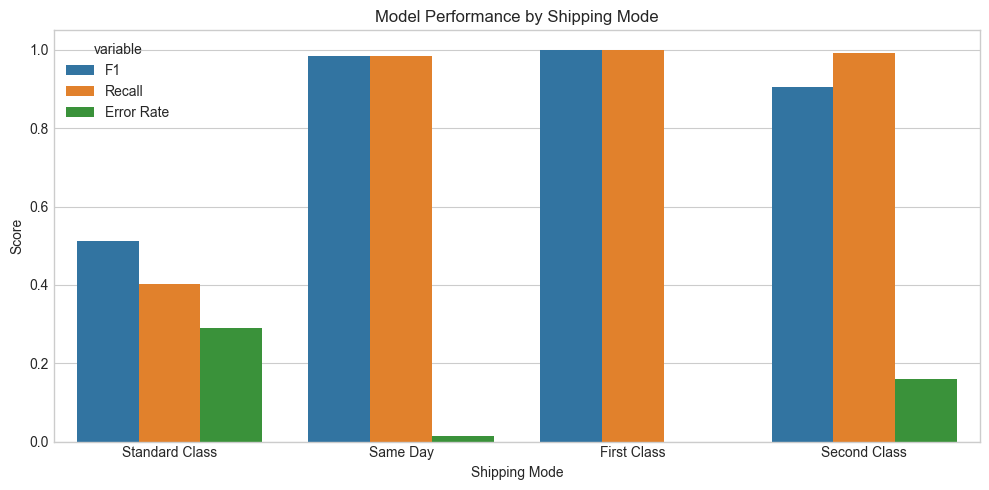

In [4]:
print("Performance by Shipping Mode:")
print("=" * 65)

for mode in analysis_df["Shipping Mode"].unique():
    subset = analysis_df[analysis_df["Shipping Mode"] == mode]
    actual = subset["actual"]
    pred = subset["predicted"]
    
    f1 = f1_score(actual, pred, zero_division=0)
    recall = recall_score(actual, pred, zero_division=0)
    precision = precision_score(actual, pred, zero_division=0)
    n = len(subset)
    
    print(f"  {mode:20s} | F1={f1:.3f} | Recall={recall:.3f} | Precision={precision:.3f} | n={n:,}")

# Visualize
ship_perf = []
for mode in analysis_df["Shipping Mode"].unique():
    subset = analysis_df[analysis_df["Shipping Mode"] == mode]
    ship_perf.append({
        "Shipping Mode": mode,
        "F1": f1_score(subset["actual"], subset["predicted"], zero_division=0),
        "Recall": recall_score(subset["actual"], subset["predicted"], zero_division=0),
        "Error Rate": 1 - (subset["correct"].mean())
    })

ship_df = pd.DataFrame(ship_perf)

fig, ax = plt.subplots(figsize=(10, 5))
ship_df_melted = ship_df.melt(id_vars="Shipping Mode", value_vars=["F1", "Recall", "Error Rate"])
sns.barplot(data=ship_df_melted, x="Shipping Mode", y="value", hue="variable", ax=ax)
ax.set_title("Model Performance by Shipping Mode")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

## 7.4 Performance by Market

Performance by Market:
  USCA            | F1=0.798 | Recall=0.741 | n=5,112
  LATAM           | F1=0.795 | Recall=0.741 | n=10,365
  Europe          | F1=0.801 | Recall=0.758 | n=9,966
  Pacific Asia    | F1=0.794 | Recall=0.740 | n=8,328
  Africa          | F1=0.862 | Recall=0.823 | n=2,333


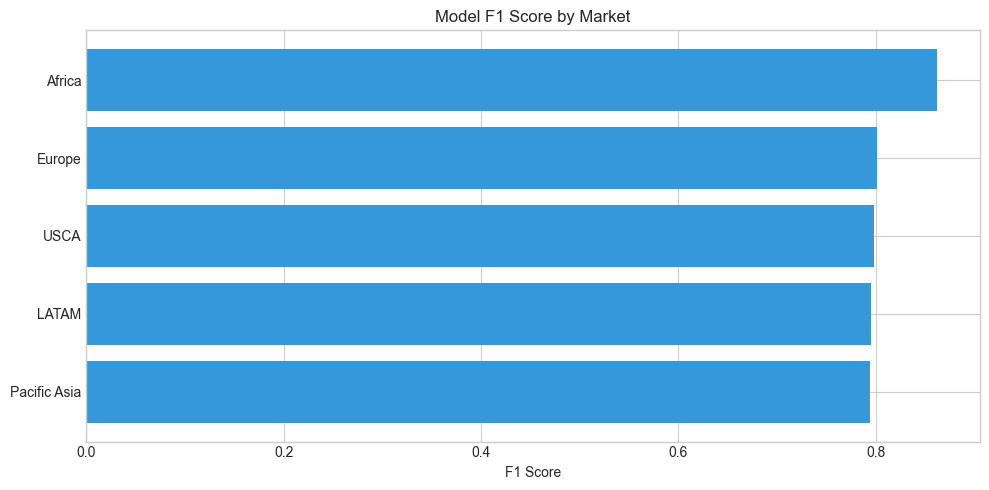

In [5]:
print("Performance by Market:")
print("=" * 65)

market_perf = []
for market in analysis_df["Market"].unique():
    subset = analysis_df[analysis_df["Market"] == market]
    actual = subset["actual"]
    pred = subset["predicted"]
    
    f1 = f1_score(actual, pred, zero_division=0)
    recall = recall_score(actual, pred, zero_division=0)
    n = len(subset)
    
    market_perf.append({"Market": market, "F1": f1, "Recall": recall, "n": n})
    print(f"  {market:15s} | F1={f1:.3f} | Recall={recall:.3f} | n={n:,}")

market_df = pd.DataFrame(market_perf)

plt.figure(figsize=(10, 5))
market_df_sorted = market_df.sort_values("F1")
plt.barh(market_df_sorted["Market"], market_df_sorted["F1"], color="#3498db")
plt.xlabel("F1 Score")
plt.title("Model F1 Score by Market")
plt.tight_layout()
plt.show()

## 7.5 Performance by Order Value Quartile

In [6]:
analysis_df["Sales_Quartile"] = pd.qcut(
    analysis_df["Sales"], q=4,
    labels=["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]
)

print("Performance by Sales Quartile:")
print("=" * 65)

for q in ["Q1 (Low)", "Q2", "Q3", "Q4 (High)"]:
    subset = analysis_df[analysis_df["Sales_Quartile"] == q]
    actual = subset["actual"]
    pred = subset["predicted"]
    
    f1 = f1_score(actual, pred, zero_division=0)
    recall = recall_score(actual, pred, zero_division=0)
    
    print(f"  {q:12s} | F1={f1:.3f} | Recall={recall:.3f} | n={len(subset):,}")

Performance by Sales Quartile:
  Q1 (Low)     | F1=0.802 | Recall=0.752 | n=9,409
  Q2           | F1=0.808 | Recall=0.756 | n=9,112
  Q3           | F1=0.798 | Recall=0.743 | n=9,084


  Q4 (High)    | F1=0.796 | Recall=0.753 | n=8,499


## 7.6 Performance by Customer Segment

In [7]:
print("Performance by Customer Segment:")
print("=" * 65)

for seg in analysis_df["Customer Segment"].unique():
    subset = analysis_df[analysis_df["Customer Segment"] == seg]
    actual = subset["actual"]
    pred = subset["predicted"]
    
    f1 = f1_score(actual, pred, zero_division=0)
    recall = recall_score(actual, pred, zero_division=0)
    
    print(f"  {seg:15s} | F1={f1:.3f} | Recall={recall:.3f} | n={len(subset):,}")

Performance by Customer Segment:
  Corporate       | F1=0.806 | Recall=0.753 | n=10,890
  Consumer        | F1=0.794 | Recall=0.744 | n=18,740
  Home Office     | F1=0.814 | Recall=0.767 | n=6,474


## 7.7 What Characterizes the Model's Mistakes?

In [8]:
# Compare feature distributions: correct vs incorrect predictions
print("Comparing incorrect vs correct predictions (key features):")
print("=" * 60)

for col in ["Sales", "Order Item Quantity", "Days for shipment (scheduled)"]:
    correct_mean = analysis_df[analysis_df["correct"] == 1][col].mean()
    incorrect_mean = analysis_df[analysis_df["correct"] == 0][col].mean()
    print(f"\n{col}:")
    print(f"  Correct predictions — mean: {correct_mean:.2f}")
    print(f"  Incorrect predictions — mean: {incorrect_mean:.2f}")

Comparing incorrect vs correct predictions (key features):

Sales:
  Correct predictions — mean: 203.19
  Incorrect predictions — mean: 207.14

Order Item Quantity:
  Correct predictions — mean: 2.12
  Incorrect predictions — mean: 2.11

Days for shipment (scheduled):
  Correct predictions — mean: 2.73
  Incorrect predictions — mean: 3.68


## Summary

**Key findings from error analysis:**

1. **False Negatives** (missed late deliveries) are typically borderline cases
   where the model's predicted probability was just below 0.5

2. **Shipping Mode** matters — some modes are harder to predict than others.
   This makes intuitive sense: Same Day shipping has less room for delay,
   while Standard Class has more variability.

3. **Market** differences exist — the model may perform better in markets
   with more training data or more consistent delivery patterns.

4. **Order value** quartiles show whether the model is biased toward
   certain price ranges.

These insights can guide future improvements:
- Lowering the threshold for poorly-served segments
- Collecting more data for underperforming markets
- Adding market-specific features

**Next step:** Model explainability with SHAP